In [28]:
#%%
import os
import sys

PROJECT_NAME = 'sales-forecasting'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'/content/drive/My Drive/Data Science/Personal/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Projects/Personal/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Projects\Personal\sales-forecasting


In [29]:
# Importing class
import matplotlib.pyplot as plt
from src.config.config import ProjectConfig
from src.data.data_loader import DataLoader
from src.data.data_cleaner import DataCleaner
from src.features.features_engineer import FeatureEngineer
from src.visualization.visualizer import DataVisualizer
from src.models.model_builder import ModelBuilder
from src.models.model_evaluator import ModelEvaluator

# Configuration
config = ProjectConfig(
    project_name="Sales Forecasting",
    raw_data_path="data/raw/sales.csv",
    processed_data_path = "data/processed/sales_clean.csv"
)

config.show_project_name()
config.show_data_paths()

# Data Loader
loader = DataLoader("data/raw/train.csv")
df = loader.load_data()
df

Project Name: Sales Forecasting
Raw Data Path: data/raw/sales.csv
Processed Data Path: data/processed/sales_clean.csv


D:\Data-Science\Projects\Personal\sales-forecasting\src\data\data_loader.py:46: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  self.dataFrame = pd.read_csv(self.file_path)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [30]:

print(df.shape)
print(df.columns)

(1017209, 9)
Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='str')


In [31]:
cleaner = DataCleaner(df)
cleaner.check_missing()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [33]:
df.sample(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
315096,220,3,2014-10-08,4710,597,1,1,0,1
455350,101,1,2014-05-19,9608,931,1,1,0,0
380807,523,3,2014-07-30,15437,1668,1,1,0,1
125162,283,5,2015-04-10,6305,641,1,0,0,1
121582,48,1,2015-04-13,4559,467,1,1,0,0
238968,862,1,2014-12-29,12753,1488,1,0,0,1
433846,897,7,2014-06-08,0,0,0,0,0,0
874011,637,4,2013-05-09,0,0,0,0,a,0
214251,172,2,2015-01-20,6157,839,1,0,0,0
757589,175,3,2013-08-21,4121,550,1,0,0,0


In [34]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [35]:
df["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [36]:
df["Store"].value_counts()

Store
1       942
2       942
3       942
4       942
5       942
       ... 
1094    758
1102    758
1104    758
1107    758
1109    758
Name: count, Length: 1115, dtype: int64

In [37]:
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [38]:
cleaner.check_missing()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [39]:
cleaner = DataCleaner(df)
cleaner.check_missing()

df_cleaned = cleaner.handle_missing(strategy="drop")
df_cleaned.shape

df_converted = cleaner.convert_types()

df_converted.dtypes


Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday           category
SchoolHoliday             int64
dtype: object

In [40]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  category      
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(7)
memory usage: 63.1 MB


In [41]:
df_converted.shape

(1017209, 9)

In [42]:
df_unique= cleaner.remove_duplicates()
df_unique.shape

(1017209, 9)

In [43]:
df_normalized = cleaner.normalize_columns()
df_normalized.columns

Index(['store', 'dayofweek', 'date', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday'],
      dtype='str')

In [44]:
df_normalized["open"].value_counts()

open
1    844392
0    172817
Name: count, dtype: int64

In [45]:
df_filtered = cleaner.filter_rows(condition_column="open", condition_column_value=1)
df_filtered["open"].value_counts()

open
1    844392
Name: count, dtype: int64

In [46]:
cleaner = DataCleaner(df)
cleaner.check_missing()

df_cleaned = cleaner.handle_missing(strategy="drop")
df_cleaned.shape

df_converted = cleaner.convert_types()
df_converted.dtypes

df_unique= cleaner.remove_duplicates()
df_unique.shape

df_normalized = cleaner.normalize_columns()
df_normalized.columns

df_filtered = cleaner.filter_rows(condition_column="open", condition_column_value=1)
df_filtered["open"].value_counts()

df_filtered.info()


<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   store          844392 non-null  int64         
 1   dayofweek      844392 non-null  int64         
 2   date           844392 non-null  datetime64[us]
 3   sales          844392 non-null  int64         
 4   customers      844392 non-null  int64         
 5   open           844392 non-null  int64         
 6   promo          844392 non-null  int64         
 7   stateholiday   844392 non-null  category      
 8   schoolholiday  844392 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(7)
memory usage: 58.8 MB


In [47]:
engineer = FeatureEngineer(df_filtered)
df_feature = engineer.add_date_part()

df_feature

,store,dayofweek,date,sales,customers,open,promo,stateholiday,schoolholiday,year,month,day
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31
...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,2013,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,2013,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,2013,1,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,2013,1,1


In [48]:
engineer = FeatureEngineer(df_filtered)
df_feature = engineer.add_date_part()

df_feature = engineer.day_of_week()

df_feature = engineer.add_holiday_flags()

df_feature = engineer.add_interaction_features()

df_feature = engineer.add_lag_features()

df_feature[["date", "sales", "sales_lag_1"]].head(10)

df_feature.isnull().sum()

df_feature = df_feature.dropna(subset=["sales_lag_1"])

df_feature.isnull().sum()



store                             0
day_of_week                       0
date                              0
sales                             0
customers                         0
open                              0
promo                             0
stateholiday                      0
schoolholiday                     0
year                              0
month                             0
day                               0
is_state_holiday                  0
is_school_holiday                 0
promo_weekday_interaction         0
promo_stateholiday_interaction    0
sales_lag_1                       0
dtype: int64

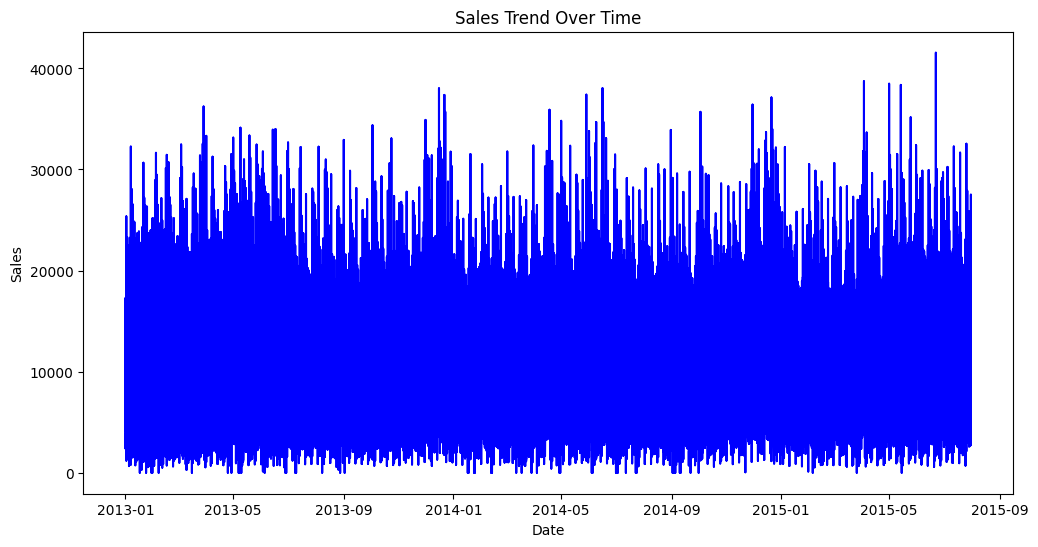

In [49]:
visualizer = DataVisualizer(df_feature)
visualizer.plot_sales_trend()

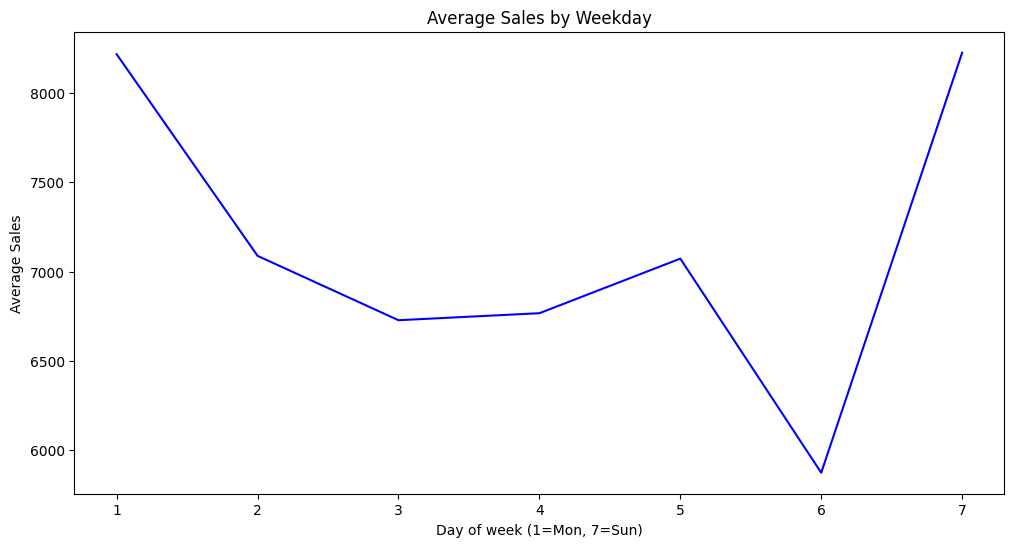

In [50]:
visualizer.plot_sales_by_weekday()

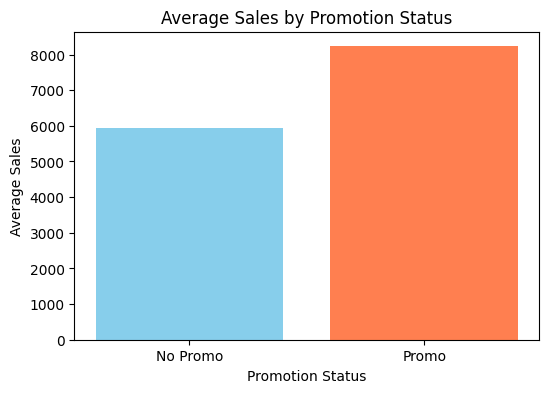

In [51]:
visualizer.plot_sales_by_promo()

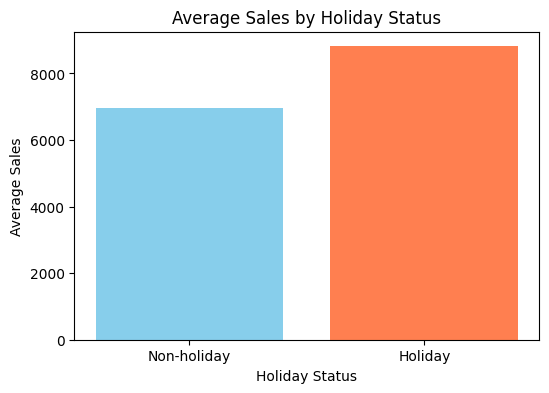

In [52]:
visualizer.plot_sales_by_holiday()

In [53]:
builder = ModelBuilder(df_feature)

X_train, X_test, y_train, y_test = builder.train_test_split(
    feature_columns=["promo", "day_of_week", "sales_lag_1"],
    target_column="sales",
    test_size=0.2,
    random_state=42)

print(f"Train/test split completed. Train size {len(X_train)}. Test size {len(X_test)}")

baseline_model = builder.train_baseline_model(X_train, y_train)
print(f"Baseline model trained on training set only: {baseline_model}")

Train/test split completed. Train size 675512. Test size 168879
Baseline model trained on training set only: LinearRegression()


In [54]:
evaluator = ModelEvaluator(X_train, y_train, X_test, y_test)
results = evaluator.compare_models()
print(f"Model comparison results: {results}")

Model comparison results: {'Linear Regression': {'RMSE': np.float64(2849.5113147403013), 'R2': 0.15410223108378995}, 'Decision Tree': {'RMSE': np.float64(3174.2466096272738), 'R2': -0.049683659833629656}, 'Random Forest': {'RMSE': np.float64(3063.3816067156795), 'R2': 0.022359220247573197}}
